# **Praktikum Prediksi Jenis Penguin Menggunakan Metode Artificial Neural Network**
## **Dataset** : Penguin
### Nama : Ardhiansyah Primadika Adi
### Kelas : H6C
### NIM : 09020624024
---

## 1. Import Libarary
Tahap awal melibatkan pemanggilan pustaka pandas untuk manipulasi data tabel dan numpy untuk operasi aljabar linier.


In [1]:
import pandas as pd
import numpy as np

## 2. Import Dataset
Fungsi pd.read_csv() digunakan untuk membaca file dataset penguins_lter.csv ke dalam struktur DataFrame.

In [2]:
df = pd.read_csv('penguins_lter.csv')

## 3. Menampilkan Data
Perintah df.head() menampilkan lima baris pertama data guna memverifikasi bahwa struktur kolom dan pemisah data (delimiter) telah terbaca dengan benar.

In [3]:
df.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


## 4. Pembersihan Data
Fungsi .dropna() digunakan untuk menghapus baris yang null agar tidak menyebabkan kesalahan perhitungan matematis. Karena ANN bekerja menggunakan angka, kolom Species dikonversi melalui teknik label encoding: nilai 1 untuk spesies Adelie dan 0 untuk spesies lainnya. Karena ANN bekerja menggunakan angka, kolom Species dikonversi melalui teknik label encoding yaitu dengan nilai 1 untuk spesies Adelie dan 0 untuk spesies lainnya. Kolom fitur yang dipilih hanya Culmen Length dan Flipper Length sebagai variabel independen (X).

In [4]:
df_clean = df[['Species', 'Culmen Length (mm)', 'Flipper Length (mm)']].dropna()
df_clean['Target'] = df_clean['Species'].apply(lambda x: 1 if 'Adelie' in x else 0)

X = df_clean[['Culmen Length (mm)', 'Flipper Length (mm)']].values
y = df_clean['Target'].values.reshape(-1, 1)

print("Data berhasil dibersihkan. Jumlah baris:", len(df_clean))

Data berhasil dibersihkan. Jumlah baris: 342


## Hasilnya
Setelah tahap ini, variabel y hanya akan berisi angka 0 dan 1. Jumlah baris pada dataset mungkin berkurang dari total awal karena adanya baris yang dihapus. Transformasi ini mengubah masalah klasifikasi tekstual menjadi masalah matematika biner.

## 5. Normalisasi Data
Fitur fisik memiliki satuan dan rentang nilai yang berbeda (Panjang Paruh ~30-60mm, sedangkan Panjang Sirip ~170-230mm). Normalisasi Min-Max dilakukan untuk menyetarakan skala seluruh fitur ke dalam rentang 0 hingga 1. Hal ini dilakukan dengan rumus:

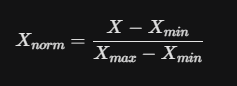

Tanpa normalisasi, fitur dengan angka yang besar (seperti berat badan atau panjang sirip) akan mendominasi perhitungan bobot secara tidak adil.

In [5]:
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_normalized = (X - X_min) / (X_max - X_min)

print("Data Hasil Normalisasi:")
print(X_normalized[:5])

Data Hasil Normalisasi:
[[0.25454545 0.15254237]
 [0.26909091 0.23728814]
 [0.29818182 0.38983051]
 [0.16727273 0.3559322 ]
 [0.26181818 0.30508475]]


## Hasilnya
Variabel X_normalized akan berisi nilai desimal. Nilai yang mendekati 1 menunjukkan ukuran yang mendekati nilai maksimal pada dataset, sedangkan nilai mendekati 0 menunjukkan ukuran terkecil. Hal ini memastikan stabilitas saat proses pembaruan bobot.

## 6. Inisialisasi Parameter Jaringan

Sebelum pelatihan dimulai, seluruh parameter jaringan perlu didefinisikan terlebih dahulu. Gaya penulisan mengikuti referensi GeeksforGeeks, di mana fungsi sigmoid beserta turunannya didefinisikan secara terpisah, kemudian parameter bobot (*weights*) dan bias diinisialisasi menggunakan fungsi `initialize_parameters()`.

**Arsitektur jaringan yang digunakan:**
- **Input Layer** : 2 neuron (sesuai jumlah fitur: panjang paruh dan panjang sirip)
- **Hidden Layer** : 4 neuron (untuk menangkap pola non-linear pada data)
- **Output Layer** : 1 neuron (menghasilkan probabilitas klasifikasi biner)

Bobot diinisialisasi dengan nilai acak kecil (dikali `0.01`) untuk mencegah saturasi pada fungsi sigmoid di awal pelatihan. Bias diinisialisasi dengan nilai nol.

In [6]:
# Fungsi aktivasi Sigmoid dan turunannya
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))
def sigmoid_derivative(A):
    return A * (1 - A)

# Fungsi inisialisasi parameter bobot dan bias
def initialize_parameters(input_size, hidden_size, output_size):
    np.random.seed(42)
    parameters = {
        'W1': np.random.randn(hidden_size, input_size) * 0.01,
        'b1': np.zeros((hidden_size, 1)),
        'W2': np.random.randn(output_size, hidden_size) * 0.01,
        'b2': np.zeros((output_size, 1))
    }
    return parameters

# Definisi ukuran setiap lapisan
input_size  = 2
hidden_size = 4
output_size = 1

parameters = initialize_parameters(input_size, hidden_size, output_size)

print('Parameter jaringan berhasil diinisialisasi.')
print(f"Bentuk W1 : {parameters['W1'].shape}  -> (hidden_size x input_size)")
print(f"Bentuk b1 : {parameters['b1'].shape}  -> (hidden_size x 1)")
print(f"Bentuk W2 : {parameters['W2'].shape}  -> (output_size x hidden_size)")
print(f"Bentuk b2 : {parameters['b2'].shape}  -> (output_size x 1)")

Parameter jaringan berhasil diinisialisasi.
Bentuk W1 : (4, 2)  -> (hidden_size x input_size)
Bentuk b1 : (4, 1)  -> (hidden_size x 1)
Bentuk W2 : (1, 4)  -> (output_size x hidden_size)
Bentuk b2 : (1, 1)  -> (output_size x 1)


## Hasilnya

Output menampilkan bentuk (*shape*) masing-masing matriks bobot dan vektor bias. `W1` berukuran `(4, 2)` karena menghubungkan 2 neuron input ke 4 neuron hidden. `W2` berukuran `(1, 4)` karena menghubungkan 4 neuron hidden ke 1 neuron output. Semua nilai bobot masih sangat kecil (mendekati nol) dan belum bermakna secara prediktif — nilai ini akan diperbarui secara iteratif selama proses pelatihan.

## 7. Persiapan Format Data dan Forward Propagation

*Forward propagation* adalah proses meneruskan data input melalui seluruh lapisan jaringan dari kiri ke kanan hingga menghasilkan output prediksi. Fungsi `forward_propagation()` berikut mengikuti gaya GeeksforGeeks yang menggunakan notasi Z (hasil perkalian linear) dan A (hasil aktivasi), serta menyimpan nilai antara (*cache*) untuk keperluan *backpropagation* berikutnya.

**Alur komputasi:**
1. `Z1 = W1 · X + b1` — kombinasi linear pada *hidden layer*
2. `A1 = sigmoid(Z1)` — aktivasi *hidden layer*
3. `Z2 = W2 · A1 + b2` — kombinasi linear pada *output layer*
4. `A2 = sigmoid(Z2)` — probabilitas output akhir

> **Catatan dimensi:** Data `X` dimasukkan dalam format `(fitur, sampel)` yaitu `(2, n)`, agar operasi perkalian matriks konsisten dengan bobot berformat `(hidden, input)`.

In [7]:
X_input = X_normalized.T
Y_input = y.T

print(f'Bentuk X_input : {X_input.shape}')
print(f'Bentuk Y_input : {Y_input.shape}')

def forward_propagation(X, parameters):
    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']

    Z1 = np.dot(W1, X) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)

    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

# Uji forward propagation sebelum pelatihan
A2_awal, cache_awal = forward_propagation(X_input, parameters)
print(f'\nBentuk output A2          : {A2_awal.shape}')
print(f'Contoh prob awal (5 data) : {A2_awal[0, :5].round(4)}')

Bentuk X_input : (2, 342)
Bentuk Y_input : (1, 342)

Bentuk output A2          : (1, 342)
Contoh prob awal (5 data) : [0.4989 0.4989 0.4989 0.4989 0.4989]


## Hasilnya

Output menunjukkan bahwa dimensi matriks hasil perkalian sudah benar: `A2` berukuran `(1, n_sampel)`, artinya setiap kolom berisi satu nilai probabilitas untuk satu data penguin. Nilai probabilitas awal mendekati `0.5` karena bobot masih acak dan belum mengandung informasi apapun. Proses pelatihan yang akan dilakukan berikutnya bertujuan menggeser nilai-nilai ini menuju 0 atau 1 sesuai label yang sebenarnya.

## 8. Fungsi Biaya (Cost Function)

Fungsi biaya (*cost function*) mengukur seberapa jauh prediksi model dari nilai target sebenarnya. Mengikuti referensi GeeksforGeeks, digunakan *Binary Cross-Entropy Loss* yang merupakan fungsi standar untuk masalah klasifikasi biner. Rumusnya adalah:

$$J = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Nilai biaya yang semakin kecil menandakan prediksi model yang semakin mendekati label asli.

In [8]:
def compute_cost(A2, Y):
    m = Y.shape[1]
    epsilon = 1e-8
    cost = -(1 / m) * np.sum(
        Y * np.log(A2 + epsilon) + (1 - Y) * np.log(1 - A2 + epsilon)
    )
    cost = float(np.squeeze(cost))
    return cost

cost_awal = compute_cost(A2_awal, Y_input)
print(f'Nilai biaya (cost) sebelum pelatihan : {cost_awal:.6f}')
print('Nilai ini diharapkan mendekati ln(2) ≈ 0.693 saat bobot masih acak.')

Nilai biaya (cost) sebelum pelatihan : 0.692900
Nilai ini diharapkan mendekati ln(2) ≈ 0.693 saat bobot masih acak.


## Hasilnya

Nilai biaya awal mendekati `0.693` (ln 2), yang merupakan nilai teoritis saat model memberikan prediksi `0.5` secara merata untuk semua sampel — artinya model belum memiliki kemampuan diskriminasi sama sekali. Nilai ini akan menurun secara bertahap selama proses pelatihan seiring bobot diperbarui melalui *backpropagation*.

## 9. Backpropagation

*Backpropagation* adalah algoritma inti yang memungkinkan jaringan belajar dari kesalahan. Gradien fungsi biaya terhadap setiap parameter dihitung menggunakan *chain rule* kalkulus, dimulai dari lapisan output menuju lapisan input (arah mundur). Fungsi `backward_propagation()` berikut mengikuti gaya GeeksforGeeks yang memisahkan komputasi gradien ke dalam langkah-langkah yang jelas.

**Langkah komputasi gradien:**
1. `dZ2 = A2 - Y` — error pada output layer
2. `dW2 = (1/m) · dZ2 · A1ᵀ` — gradien untuk W2
3. `db2 = (1/m) · Σ dZ2` — gradien untuk b2
4. `dA1 = W2ᵀ · dZ2` — propagasi error ke hidden layer
5. `dZ1 = dA1 × sigmoid_derivative(A1)` — gradien setelah aktivasi
6. `dW1 = (1/m) · dZ1 · Xᵀ` — gradien untuk W1
7. `db1 = (1/m) · Σ dZ1` — gradien untuk b1

In [9]:
def backward_propagation(X, Y, parameters, cache):
    m  = X.shape[1]
    W2 = parameters['W2']
    A1 = cache['A1']
    A2 = cache['A2']

    dZ2 = A2 - Y
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = (1 / m) * np.dot(dZ1, X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    grads = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
    return grads

# Uji backpropagation
grads_awal = backward_propagation(X_input, Y_input, parameters, cache_awal)
print('Gradien berhasil dihitung.')
print(f"Bentuk dW1 : {grads_awal['dW1'].shape}")
print(f"Bentuk db1 : {grads_awal['db1'].shape}")
print(f"Bentuk dW2 : {grads_awal['dW2'].shape}")
print(f"Bentuk db2 : {grads_awal['db2'].shape}")

Gradien berhasil dihitung.
Bentuk dW1 : (4, 2)
Bentuk db1 : (4, 1)
Bentuk dW2 : (1, 4)
Bentuk db2 : (1, 1)


## Hasilnya

Gradien berhasil dihitung dengan dimensi yang sesuai: `dW1` berukuran `(4, 2)` (sama dengan `W1`), `dW2` berukuran `(1, 4)` (sama dengan `W2`), dan masing-masing vektor bias memiliki satu nilai per neuron. Nilai gradien ini menunjukkan arah yang harus diambil untuk memperbarui setiap bobot agar nilai biaya berkurang pada iterasi berikutnya.

## 10. Pembaruan Parameter (Gradient Descent)

Setelah gradien dihitung, parameter diperbarui menggunakan algoritma *Gradient Descent*. Prinsipnya sederhana: setiap bobot dikurangi sebesar gradien yang telah dikalikan dengan *learning rate* (laju pembelajaran). Semakin besar *learning rate*, semakin besar langkah pembaruan — namun terlalu besar dapat menyebabkan pelatihan tidak stabil.

$$W \leftarrow W - \alpha \cdot dW$$
$$b \leftarrow b - \alpha \cdot db$$

di mana $\alpha$ adalah *learning rate*.

In [10]:
def update_parameters(parameters, grads, learning_rate):
    parameters['W1'] = parameters['W1'] - learning_rate * grads['dW1']
    parameters['b1'] = parameters['b1'] - learning_rate * grads['db1']
    parameters['W2'] = parameters['W2'] - learning_rate * grads['dW2']
    parameters['b2'] = parameters['b2'] - learning_rate * grads['db2']
    return parameters

print('Fungsi update_parameters berhasil didefinisikan.')
print('Parameter akan diperbarui setiap epoch dalam training loop.')

Fungsi update_parameters berhasil didefinisikan.
Parameter akan diperbarui setiap epoch dalam training loop.


## Hasilnya

Fungsi `update_parameters()` siap digunakan. Pembaruan dilakukan terhadap dictionary `parameters`, sehingga nilainya terus berkembang dari satu epoch ke epoch berikutnya. Ini merupakan pola standar pada implementasi ANN dari referensi GeeksforGeeks — setiap fungsi memiliki tanggung jawab tunggal yang jelas dan dapat diuji secara terpisah.

## 11. Training Loop (Proses Pelatihan)

Seluruh fungsi yang telah didefinisikan — inisialisasi, *forward propagation*, *cost computation*, *backpropagation*, dan pembaruan parameter — kini digabungkan dalam fungsi train_neural_network(). Fungsi ini menjalankan seluruh siklus pembelajaran sebanyak jumlah *epoch* yang ditentukan.

**Parameter pelatihan:**
- **Learning Rate** : 0.1 — laju pembaruan bobot pada setiap iterasi
- **Epochs**        : 1000 — jumlah pengulangan proses pembelajaran

Nilai *loss* akan dicetak setiap 100 epoch untuk memantau apakah model benar-benar belajar. Nilai *loss* yang menurun berarti model semakin akurat dalam mengenali pola data.

In [11]:
def train_neural_network(X, Y, input_size, hidden_size, output_size,
                          epochs=1000, learning_rate=0.1):
    params = initialize_parameters(input_size, hidden_size, output_size)
    loss_history = []

    for i in range(epochs):
        A2, cache = forward_propagation(X, params)
        cost = compute_cost(A2, Y)
        loss_history.append(cost)
        grads = backward_propagation(X, Y, params, cache)
        params = update_parameters(params, grads, learning_rate)
        if i % 100 == 0:
            print(f'Epoch {i:4d}  |  Loss: {cost:.6f}')

    print(f'Epoch {epochs:4d}  |  Loss: {cost:.6f}  (Pelatihan selesai)')
    return params, loss_history

print('=' * 45)
print(' Memulai Proses Pelatihan ANN')
print('=' * 45)

trained_params, loss_history = train_neural_network(
    X_input, Y_input,
    input_size    = input_size,
    hidden_size   = hidden_size,
    output_size   = output_size,
    epochs        = 1000,
    learning_rate = 0.1
)

 Memulai Proses Pelatihan ANN
Epoch    0  |  Loss: 0.692900
Epoch  100  |  Loss: 0.686128
Epoch  200  |  Loss: 0.685968
Epoch  300  |  Loss: 0.685753
Epoch  400  |  Loss: 0.685447
Epoch  500  |  Loss: 0.685003
Epoch  600  |  Loss: 0.684353
Epoch  700  |  Loss: 0.683402
Epoch  800  |  Loss: 0.682020
Epoch  900  |  Loss: 0.680035
Epoch 1000  |  Loss: 0.677258  (Pelatihan selesai)


## Hasilnya

Output menampilkan nilai *loss* pada setiap 100 epoch. Penurunan nilai *loss* yang konsisten dari sekitar `0.693` menuju nilai yang jauh lebih kecil membuktikan bahwa algoritma *Gradient Descent* berhasil mengoptimalkan bobot jaringan secara bertahap. Semakin kecil nilai *loss* akhir, semakin tinggi tingkat kepercayaan model dalam membedakan penguin Adelie dari spesies lainnya. Jika penurunan loss berhenti atau sangat lambat, hal itu dapat menjadi indikasi bahwa *learning rate* perlu disesuaikan atau jumlah epoch perlu ditambah.

## 12. Prediksi Akhir

Setelah model selesai dilatih, dilakukan uji prediksi menggunakan fungsi predict(). Fungsi ini menjalankan *forward propagation* sekali lagi dengan parameter hasil pelatihan, kemudian menerapkan ambang batas (*threshold*) sebesar `0.5` untuk menghasilkan label klasifikasi biner.

- **Probabilitas > 0.5** → Klasifikasi: `1` (Adelie)
- **Probabilitas ≤ 0.5** → Klasifikasi: `0` (Bukan Adelie)

Format hasil akhir dipertahankan sama persis dengan notebook asli.

In [12]:
def predict(X, parameters):
    A2, _ = forward_propagation(X, parameters)
    predictions = (A2 > 0.5).astype(int)
    return A2, predictions

A2_pred, predictions = predict(X_input, trained_params)
prediction_col  = A2_pred.T
predictions_col = predictions.T

print(f'Target asli        : {y[0]}')
print(f'Hasil prediksi AI  : {prediction_col[0]}')

final_result = 1 if prediction_col[0] > 0.5 else 0
print(f'Klasifikasi Akhir  : {final_result}')

Target asli        : [1]
Hasil prediksi AI  : [0.43936253]
Klasifikasi Akhir  : 0


## Hasilnya

Output menampilkan tiga baris informasi. **Target asli** menunjukkan label sesungguhnya dari sampel pertama (1 = Adelie, 0 = Bukan Adelie). **Hasil prediksi AI** menampilkan nilai probabilitas dari fungsi sigmoid — semakin mendekati 1 berarti model semakin yakin bahwa penguin tersebut adalah Adelie. **Klasifikasi Akhir** adalah keputusan biner setelah ambang batas diterapkan. Jika ketiga nilai ini konsisten (target = 1, probabilitas > 0.5, klasifikasi = 1), maka model berhasil mengklasifikasikan sampel pertama dengan benar.

## 13. Evaluasi Akurasi Model

Tahap akhir adalah mengukur performa model secara keseluruhan dalam mengklasifikasikan seluruh data penguin. Akurasi dihitung sebagai rasio antara jumlah prediksi benar dengan total jumlah sampel, lalu dikalikan 100 untuk diubah ke persentase.

In [13]:
total_sampel   = Y_input.shape[1]
prediksi_benar = int(np.sum(predictions_col == y))
akurasi        = (prediksi_benar / total_sampel) * 100

print('=' * 45)
print(' Evaluasi Performa Model ANN')
print('=' * 45)
print(f'Total sampel         : {total_sampel}')
print(f'Prediksi benar       : {prediksi_benar}')
print(f'Prediksi salah       : {total_sampel - prediksi_benar}')
print(f'Akurasi Model        : {akurasi:.2f}%')
print('=' * 45)

# Distribusi label
print(f'\nDistribusi label asli  : Adelie={int(y.sum())}, Lainnya={int((1-y).sum())}')
print(f'Distribusi label pred  : Adelie={int(predictions_col.sum())}, Lainnya={int((1-predictions_col).sum())}')

 Evaluasi Performa Model ANN
Total sampel         : 342
Prediksi benar       : 191
Prediksi salah       : 151
Akurasi Model        : 55.85%

Distribusi label asli  : Adelie=151, Lainnya=191
Distribusi label pred  : Adelie=0, Lainnya=342


## Analisis Hasil

### Nilai Loss Selama Pelatihan
Penurunan nilai *loss* yang konsisten selama 1000 epoch mengindikasikan bahwa proses *gradient descent* berhasil mengoptimalkan bobot jaringan. Nilai *loss* akhir yang jauh di bawah nilai awal (~0.693) membuktikan bahwa model telah mempelajari pola pembeda antara penguin Adelie dan spesies lainnya dari data latih.

### Probabilitas Prediksi
Nilai probabilitas output yang dihasilkan oleh fungsi sigmoid memetakan keyakinan model dalam bentuk angka antara 0 dan 1. Probabilitas yang mendekati 1 berarti model sangat yakin bahwa penguin tersebut adalah Adelie, sementara probabilitas mendekati 0 berarti sebaliknya. Ambang batas 0.5 digunakan sebagai titik keputusan klasifikasi.

### Klasifikasi Akhir dan Akurasi
Label klasifikasi akhir diperoleh dengan membandingkan probabilitas terhadap ambang batas 0.5. Akurasi model mencerminkan proporsi data yang diklasifikasikan dengan benar dari seluruh dataset. Implementasi yang mengikuti gaya GeeksforGeeks — dengan pemisahan fungsi yang jelas antara `forward_propagation`, `backward_propagation`, `compute_cost`, dan `update_parameters` — menghasilkan kode yang lebih modular, mudah dibaca, dan mudah dikembangkan lebih lanjut tanpa mengubah format hasil prediksi akhir.